# Clustering with K-Means

Makes use of "unsupervised" learning algorithms. These algorithms don't make use of a target, instead they learn a property of the data. The idea is to discover features that may be important or un-measured in the data. Data points are clustered based on how similar they are to eachother. Adding labels to these clusters and including them in the features can help the model untangle complex relationships.

### Cluster Labels as a Feature

When applied to a single real-valued feature, clustering acts like traditional binning or "discretization" transform. On multiple features it's like a multi dimensional binning technique.

Clusters define a new categorical variable. By breaking data into clusters, it can be easier and more descriptive for the behavior of each cluster to be defined in a linear manner.

### k-Mean Clustering

k-Mean clustering is good for feature engineering, but other algorithms may be better for other applications. Best to do more research when using clustering algorithms.

**K-means clustering** measures similarity using ordinary straight-line distance (Euclidean distance, in other words). It creates clusters by placing a number of points, called **centroids**, inside the feature-space. Each point in the dataset is assigned to the cluster of whichever centroid it's closest to. The "k" in "k-means" is how many centroids (that is, clusters) it creates. You define the k yourself.

You could imagine each centroid capturing points through a sequence of radiating circles. When sets of circles from competing centroids overlap they form a line. The result is what's called a **Voronoi tessallation**. The tessallation shows you to what clusters future data will be assigned; the tessallation is essentially what k-means learns from its training data.

#### Paramters
* n_clusters: number of centroids created in initialization, also number of final clusters
* max_iter: The maximum number of iterations the algorithm will take to reach it's final state.
* n_init: Number of time the algorithm will re-initialize with random weights to try and find the best clustering.

### Example: California Housing

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans

plt.style.use("seaborn-v0_8-whitegrid")
plt.rc("figure", autolayout=True)
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=14,
    titlepad=10,
)

df = pd.read_csv("../data/housing.csv")
X = df.loc[:, ["MedInc", "Latitude", "Longitude"]]
X.head()

,MedInc,Latitude,Longitude
0,8.3252,37.88,-122.23
1,8.3014,37.86,-122.22
2,7.2574,37.85,-122.24
3,5.6431,37.85,-122.25
4,3.8462,37.85,-122.25


In [7]:
# Create cluster feature
kmeans = KMeans(n_clusters=6, n_init=10)
X["Cluster"] = kmeans.fit_predict(X)
X["Cluster"] = X["Cluster"].astype("category")

X.head()

,MedInc,Latitude,Longitude,Cluster,MedHouseVal
0,8.3252,37.88,-122.23,1,4.526
1,8.3014,37.86,-122.22,1,3.585
2,7.2574,37.85,-122.24,1,3.521
3,5.6431,37.85,-122.25,1,3.413
4,3.8462,37.85,-122.25,1,3.422


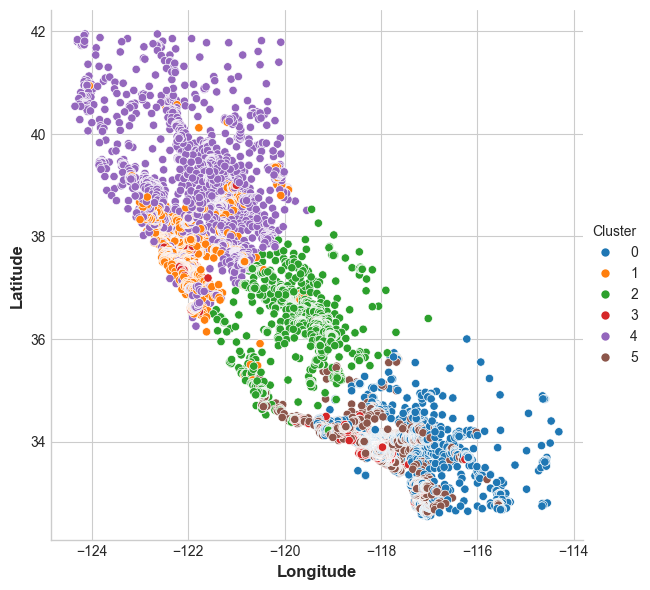

In [8]:
sns.relplot(
    x="Longitude", y="Latitude", hue="Cluster", data=X, height=6,
);

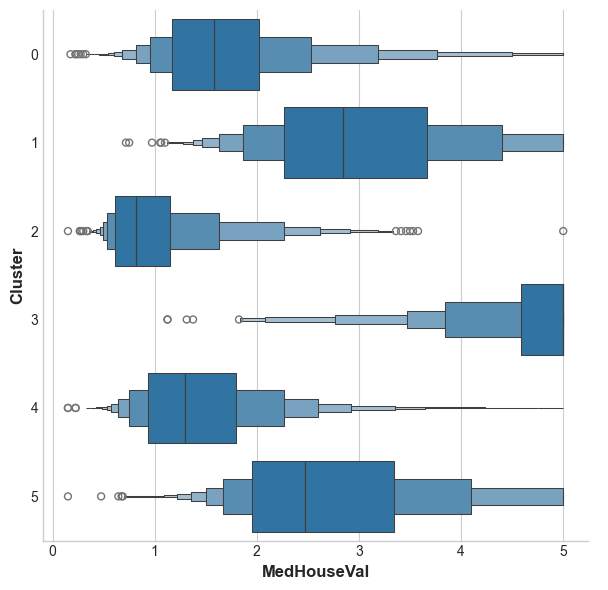

In [9]:
X["MedHouseVal"] = df["MedHouseVal"]
sns.catplot(x="MedHouseVal", y="Cluster", data=X, kind="boxen", height=6);

### Scaling

k-mean clustering is sensitive to scale so it may be good to rescale or normalize data so it is on roughly the same scale. This process requires some thought and shouldn't be automatic. Data that is relatively similar generally doesn't need to be rescaled, but unrelated values likely do.

### Cluster-Distance Features

Use the fit_transform rather than the fit_predict methdo of KMeans to return the distance of each data point from the centroid rather than the cluster classification.